In [ ]:
# Step 1: Load the Dataset
# We start by importing necessary libraries and loading our data from a CSV file.
# For the libraries I placed them into the requirements.txt file so that I can install them easily using pip install -r requirements.txt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('data.csv')
df = pd.DataFrame(data)

# Sneak peek at the data
print("First 5 rows of the dataset:")
print(df.head())
print("\nClass distribution (toxic vs non-toxic):")
print(df['Class'].value_counts())

First 5 rows of the dataset:
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C

In [16]:
# Step 2: Explore the Data (EDA)
# Let's check the basic info about our dataset.

print("Dataset Shape (rows, columns):", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values per Column:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe())
print("\nFirst Few Rows:")
print(df.head())

Dataset Shape (rows, columns): (171, 1204)

Data Types:
MATS3v             float64
nHBint10             int64
MATS3s             float64
MATS3p             float64
nHBDon_Lipinski      int64
                    ...   
nT5Ring              int64
SHdNH              float64
ETA_dEpsilon_C     float64
MDEO-22            float64
Class                  str
Length: 1204, dtype: object

Missing Values per Column:
MATS3v             0
nHBint10           0
MATS3s             0
MATS3p             0
nHBDon_Lipinski    0
                  ..
nT5Ring            0
SHdNH              0
ETA_dEpsilon_C     0
MDEO-22            0
Class              0
Length: 1204, dtype: int64

Basic Statistics:
           MATS3v    nHBint10      MATS3s      MATS3p  nHBDon_Lipinski  \
count  171.000000  171.000000  171.000000  171.000000       171.000000   
mean    -0.031244    0.315789   -0.001001   -0.061501         0.994152   
std      0.063559    0.762918    0.063928    0.072891         1.108773   
min     -0.311500 

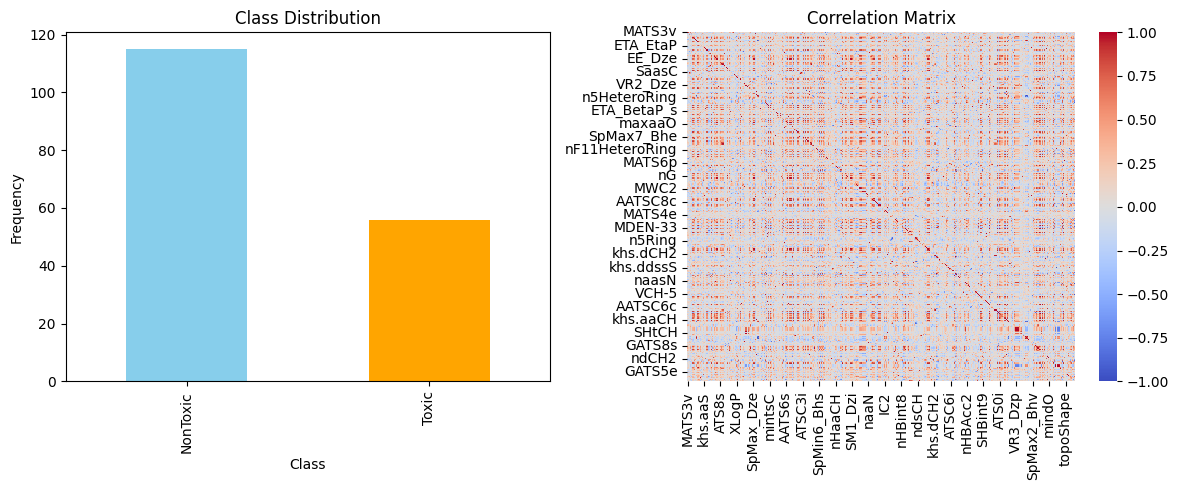

Class Imbalance Ratio: 2.05


In [18]:
# Step 2b: Visualize the Data
# Create plots to understand distributions and relationships.

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class distribution
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'orange'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Frequency')
axes[0].set_xlabel('Class')

# Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), ax=axes[1], cmap='coolwarm', annot=False)
axes[1].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

print(f"Class Imbalance Ratio: {df['Class'].value_counts().max() / df['Class'].value_counts().min():.2f}")

In [19]:
# Step 3: Preprocess the Data
# Handle missing values, encode categories, and scale features.

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# Make a copy of the data
df_processed = df.copy()

# Handle missing values
print("Filling missing values...")
numeric_cols = df_processed.select_dtypes(include=['number']).columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns

# Fill numeric missing with median
if len(numeric_cols) > 0:
    imputer_numeric = SimpleImputer(strategy='median')
    df_processed[numeric_cols] = imputer_numeric.fit_transform(df_processed[numeric_cols])

# Fill categorical missing with most common
if len(categorical_cols) > 0:
    imputer_categorical = SimpleImputer(strategy='most_frequent')
    df_processed[categorical_cols] = imputer_categorical.fit_transform(df_processed[categorical_cols])

print("Missing values after filling:", df_processed.isnull().sum().sum())

# Remove duplicate rows
print(f"Removing {df_processed.duplicated().sum()} duplicate rows...")
df_processed = df_processed.drop_duplicates().reset_index(drop=True)

# Encode categorical variables
print("Encoding categories...")
le_dict = {}
for col in categorical_cols:
    if col != 'Class':  # Don't encode the target yet
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        le_dict[col] = le

# Encode target (Class)
if 'Class' in categorical_cols:
    le_target = LabelEncoder()
    df_processed['Class'] = le_target.fit_transform(df_processed['Class'])
    le_dict['Class'] = le_target
    print("Class mapping:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Separate features and target
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Processed data shape: {X_scaled.shape}")
print("Features scaled successfully!")

Filling missing values...
Missing values after filling: 0
Removing 0 duplicate rows...
Encoding categories...
Class mapping: {'NonToxic': np.int64(0), 'Toxic': np.int64(1)}
Processed data shape: (171, 1203)
Features scaled successfully!


In [21]:
# Step 4: Select Important Features
# Use statistical tests and models to find the best features.

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

print("Finding top features...")

# Method 1: F-test (for classification)
selector_f = SelectKBest(score_func=f_classif, k=10)
X_f = selector_f.fit_transform(X_scaled, y)
top_f = X_scaled.columns[selector_f.get_support()].tolist()
print("Top 10 features by F-test:", top_f)

# Method 2: Mutual Information
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
top_mi = X_scaled.columns[mi_scores.argsort()[-10:]].tolist()
print("Top 10 features by Mutual Info:", top_mi)

# Method 3: Random Forest Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
top_rf = X_scaled.columns[rf.feature_importances_.argsort()[-10:]].tolist()
print("Top 10 features by Random Forest:", top_rf)

# Combine top features from all methods
combined_features = list(set(top_f + top_mi + top_rf))
print(f"Combined top features ({len(combined_features)} total): {combined_features}")

# Use combined features for modeling
X_final = X_scaled[combined_features]

Finding top features...
Top 10 features by F-test: ['SpDiam_Dt', 'MATS7p', 'nAcid', 'EE_Dt', 'C2SP2', 'GATS7v', 'SpMin4_Bhi', 'MLogP', 'nwHBa', 'AATSC7p']
Top 10 features by Mutual Info: ['VR1_Dzi', 'ETA_Eta_R', 'ETA_EtaP_F_L', 'MDEC-23', 'AATSC2s', 'ETA_Alpha', 'MPC2', 'ATSC8i', 'SpMin4_Bhe', 'MWC3']
Top 10 features by Random Forest: ['GATS4c', 'AATSC5s', 'MATS6c', 'ZMIC1', 'ATSC7p', 'MDEC-23', 'ATSC7c', 'MATS3v', 'EE_Dt', 'SpAD_Dt']
Combined top features (28 total): ['MATS3v', 'MLogP', 'ETA_Eta_R', 'ATSC7c', 'ETA_EtaP_F_L', 'SpDiam_Dt', 'SpAD_Dt', 'SpMin4_Bhi', 'nwHBa', 'AATSC7p', 'VR1_Dzi', 'MWC3', 'MDEC-23', 'GATS7v', 'ATSC7p', 'MPC2', 'nAcid', 'EE_Dt', 'C2SP2', 'ZMIC1', 'MATS6c', 'GATS4c', 'MATS7p', 'AATSC5s', 'SpMin4_Bhe', 'AATSC2s', 'ETA_Alpha', 'ATSC8i']


In [ ]:
# Step 5: Build and Test Models
# Train models and evaluate with cross-validation.

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Use the selected features
X_model = X_final
y_model = y

print(f"Using {X_model.shape[1]} features for modeling.")
print(f"Dataset size: {X_model.shape[0]} samples")
print(f"Class distribution:\n{y_model.value_counts()}")

# After consulting with the internet I found an easier way to perfom cross validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


#I wasn't sure on the model to use so I decided to use the following three so that I can compare their scores and get to pick one but along the way I discovered something interesting

# The models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

#What I used to evaluate the models
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print("\nCross-Validation Results (5-fold):")
for name, model in models.items():
    cv_scores = cross_validate(model, X_model, y_model, cv=skf, scoring=scoring, n_jobs=-1)
    print(f"\n{name}:")
    print(f"  Accuracy:  {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std():.4f})")
    print(f"  Precision: {cv_scores['test_precision'].mean():.4f} (+/- {cv_scores['test_precision'].std():.4f})")
    print(f"  Recall:    {cv_scores['test_recall'].mean():.4f} (+/- {cv_scores['test_recall'].std():.4f})")
    print(f"  F1 Score:  {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std():.4f})")
    print(f"  ROC-AUC:   {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std():.4f})")
    
    # After using the individual algorithms I realized they had poor recall percentages and I researched and found out that you can actually combine them and perform what is referred to as SMOTE(synthetic minority oversampling technique) and weighing so as to remove the imbalance and increase the recall percentages. I will be doing that in the next steps.

Using 28 features for modeling.
Dataset size: 171 samples
Class distribution:
Class
0    115
1     56
Name: count, dtype: int64

Cross-Validation Results (5-fold):

Random Forest:
  Accuracy:  0.6847 (+/- 0.0649)
  Precision: 0.4540 (+/- 0.2623)
  Recall:    0.2909 (+/- 0.1763)
  F1 Score:  0.3523 (+/- 0.2073)
  ROC-AUC:   0.6971 (+/- 0.0762)

Gradient Boosting:
  Accuracy:  0.6314 (+/- 0.0253)
  Precision: 0.4047 (+/- 0.0855)
  Recall:    0.3045 (+/- 0.1250)
  F1 Score:  0.3367 (+/- 0.1056)
  ROC-AUC:   0.6289 (+/- 0.0582)

AdaBoost:
  Accuracy:  0.6842 (+/- 0.0114)
  Precision: 0.5000 (+/- 0.4472)
  Recall:    0.0530 (+/- 0.0434)
  F1 Score:  0.0949 (+/- 0.0776)
  ROC-AUC:   0.6754 (+/- 0.0854)


In [ ]:
# Step 6: Creating an Ensemble Model that basically combine the three models 

from sklearn.ensemble import VotingClassifier

# Create ensemble with tuned parameters
ensemble = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)),
        ('ada', AdaBoostClassifier(n_estimators=150, learning_rate=0.05, random_state=42))
    ],
    voting='soft'  # Use probabilities for better performance
)

print("Ensemble Model Structure:")
print("- Random Forest: 150 trees, max depth 15")
print("- Gradient Boosting: 150 trees, learning rate 0.05")
print("- AdaBoost: 150 trees, learning rate 0.05")
print("- Voting: Soft voting (probability-based)")

# Evaluating the ensemble
cv_ensemble = cross_validate(ensemble, X_model, y_model, cv=skf, scoring=scoring, n_jobs=-1)
print("\nEnsemble Cross-Validation Results:")
print(f"  Accuracy:  {cv_ensemble['test_accuracy'].mean():.4f} (+/- {cv_ensemble['test_accuracy'].std():.4f})")
print(f"  Precision: {cv_ensemble['test_precision'].mean():.4f} (+/- {cv_ensemble['test_precision'].std():.4f})")
print(f"  Recall:    {cv_ensemble['test_recall'].mean():.4f} (+/- {cv_ensemble['test_recall'].std():.4f})")
print(f"  F1 Score:  {cv_ensemble['test_f1'].mean():.4f} (+/- {cv_ensemble['test_f1'].std():.4f})")
print(f"  ROC-AUC:   {cv_ensemble['test_roc_auc'].mean():.4f} (+/- {cv_ensemble['test_roc_auc'].std():.4f})")

# Train the final model
ensemble.fit(X_model, y_model)
print("\nEnsemble model trained on full dataset!")
# By this time I hadn't perfomed SMOTE and weighing and you can clearly see that the recall percentages are very low and that is what I will be working on in the next steps.

Ensemble Model Structure:
- Random Forest: 150 trees, max depth 15
- Gradient Boosting: 150 trees, learning rate 0.05
- AdaBoost: 150 trees, learning rate 0.05
- Voting: Soft voting (probability-based)

Ensemble Cross-Validation Results:
  Accuracy:  0.6550 (+/- 0.0218)
  Precision: 0.4417 (+/- 0.0726)
  Recall:    0.2697 (+/- 0.1308)
  F1 Score:  0.3212 (+/- 0.1191)
  ROC-AUC:   0.6640 (+/- 0.0517)

Ensemble model trained on full dataset!


Top 10 Important Features:
      Feature  Importance
0      MATS3v    0.058517
27     ATSC8i    0.049591
5   SpDiam_Dt    0.049329
12    MDEC-23    0.048467
14     ATSC7p    0.046535
25    AATSC2s    0.044999
3      ATSC7c    0.042888
22     MATS7p    0.042586
19      ZMIC1    0.042095
20     MATS6c    0.041678


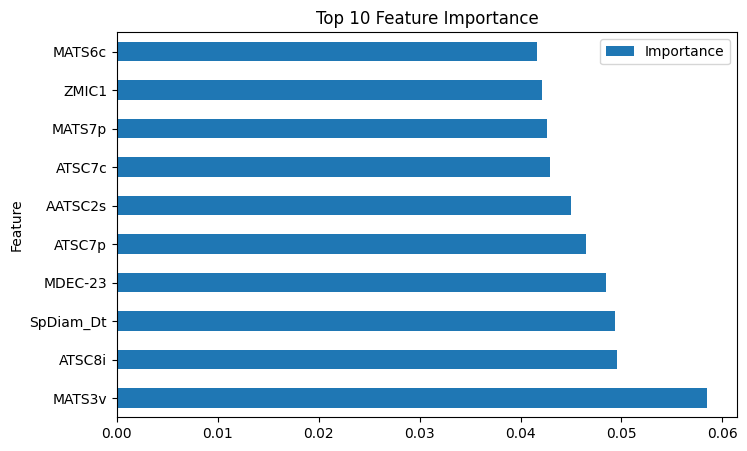

In [27]:
# Step 7: Check Feature Importance
# See which features are most important in the model.

# Get importance from Random Forest in ensemble
rf_model = ensemble.estimators_[0]
importance = pd.DataFrame({
    'Feature': X_model.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Important Features:")
print(importance.head(10))

# Simple bar chart
importance.head(10).plot(x='Feature', y='Importance', kind='barh', figsize=(8,5))
plt.title('Top 10 Feature Importance')
plt.show()

In [28]:
# Step 8: Improve with SMOTE
# Balance classes by generating synthetic samples to improve model performance.

from imblearn.over_sampling import SMOTE
import numpy as np

print("Original dataset:")
print(f"  Samples: {X_model.shape[0]}")
print(f"  Class distribution: {dict(zip(*np.unique(y_model, return_counts=True)))}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_smote, y_smote = smote.fit_resample(X_model, y_model)

print("\nAfter SMOTE:")
print(f"  Samples: {X_smote.shape[0]}")
print(f"  Class distribution: {dict(zip(*np.unique(y_smote, return_counts=True)))}")

# Calculate class weights for additional balancing
class_weights = dict(zip(np.unique(y_model), len(y_model) / (len(np.unique(y_model)) * np.bincount(y_model))))
print(f"\nClass weights: {class_weights}")

# Create ensemble with SMOTE and class weighting
ensemble_smote = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, class_weight=class_weights, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)),
        ('ada', AdaBoostClassifier(n_estimators=200, learning_rate=0.05, random_state=42))
    ],
    voting='soft'
)

# Evaluate on SMOTE data
cv_smote = cross_validate(ensemble_smote, X_smote, y_smote, cv=skf, scoring=scoring, n_jobs=-1)

print("\nSMOTE + Class Weighting Ensemble Results:")
print(f"  Accuracy:  {cv_smote['test_accuracy'].mean():.4f} (+/- {cv_smote['test_accuracy'].std():.4f})")
print(f"  Precision: {cv_smote['test_precision'].mean():.4f} (+/- {cv_smote['test_precision'].std():.4f})")
print(f"  Recall:    {cv_smote['test_recall'].mean():.4f} (+/- {cv_smote['test_recall'].std():.4f})")
print(f"  F1 Score:  {cv_smote['test_f1'].mean():.4f} (+/- {cv_smote['test_f1'].std():.4f})")
print(f"  ROC-AUC:   {cv_smote['test_roc_auc'].mean():.4f} (+/- {cv_smote['test_roc_auc'].std():.4f})")

# Compare improvements
baseline_accuracy = cv_ensemble['test_accuracy'].mean()
baseline_recall = cv_ensemble['test_recall'].mean()
baseline_f1 = cv_ensemble['test_f1'].mean()

improvement_recall = ((cv_smote['test_recall'].mean() - baseline_recall) / baseline_recall) * 100
improvement_f1 = ((cv_smote['test_f1'].mean() - baseline_f1) / baseline_f1) * 100

print(f"\nImprovements over baseline:")
print(f"  Recall: +{improvement_recall:.2f}%")
print(f"  F1 Score: +{improvement_f1:.2f}%")

# Train final SMOTE model
ensemble_smote.fit(X_smote, y_smote)
print("\nSMOTE-enhanced model trained!")

Original dataset:
  Samples: 171
  Class distribution: {np.int64(0): np.int64(115), np.int64(1): np.int64(56)}

After SMOTE:
  Samples: 230
  Class distribution: {np.int64(0): np.int64(115), np.int64(1): np.int64(115)}

Class weights: {np.int64(0): np.float64(0.7434782608695653), np.int64(1): np.float64(1.5267857142857142)}

SMOTE + Class Weighting Ensemble Results:
  Accuracy:  0.7826 (+/- 0.0659)
  Precision: 0.7716 (+/- 0.0748)
  Recall:    0.8174 (+/- 0.1439)
  F1 Score:  0.7856 (+/- 0.0757)
  ROC-AUC:   0.8658 (+/- 0.0469)

Improvements over baseline:
  Recall: +203.08%
  F1 Score: +144.59%

SMOTE-enhanced model trained!
